# Stock Market Prediction System

## Data Science Internship – Project Phase 2

### Project Overview

This project analyzes historical stock market data and predicts future stock prices using Data Science and Machine Learning techniques.

The project includes:

- Historical stock data collection
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Moving average analysis
- Correlation analysis
- Machine Learning model development
- Model evaluation
- Actual vs Predicted price comparison
- Future stock price prediction

### Machine Learning Models

The following regression algorithms will be evaluated:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

### Evaluation Metrics

The models will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- 

In [5]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# ============================================
# STOCK CONFIGURATION
# ============================================

stock_symbol = "AAPL"

start_date = "2018-01-01"
end_date = "2026-01-01"

print("Stock Symbol:", stock_symbol)
print("Start Date:", start_date)
print("End Date:", end_date)

Stock Symbol: AAPL
Start Date: 2018-01-01
End Date: 2026-01-01


In [9]:
# ============================================
# DOWNLOAD HISTORICAL STOCK DATA
# ============================================

stock_data = yf.download(
    stock_symbol,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

print("Stock data downloaded successfully!")
print("Dataset shape:", stock_data.shape)


[*********************100%***********************]  1 of 1 completed

Stock data downloaded successfully!
Dataset shape: (2011, 6)


In [11]:
# FIRST FIVE RECORDS
stock_data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-01-02,40.232368,43.064999,43.075001,42.314999,42.540001,102223600
2018-01-03,40.225365,43.057499,43.637501,42.990002,43.132500,118071600
2018-01-04,40.412216,43.257500,43.367500,43.020000,43.134998,89738400
2018-01-05,40.872318,43.750000,43.842499,43.262501,43.360001,94640000
2018-01-08,40.720524,43.587502,43.902500,43.482498,43.587502,82271200


In [13]:
# LAST FIVE RECORDS
stock_data.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-12-24,273.066711,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.657867,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.016876,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.338684,273.079987,274.079987,272.279999,272.809998,22139600
2025-12-31,271.122009,271.859985,273.679993,271.750000,273.059998,27293600


In [15]:
# DATASET DIMENSIONS

print("Rows:", stock_data.shape[0])
print("Columns:", stock_data.shape[1])

Rows: 2011
Columns: 6


In [17]:
# COLUMN NAMES
print(stock_data.columns)

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [19]:
# DATA CLEANING & PREPROCESSING

# Make a copy of the downloaded dataset
clean_data = stock_data.copy()

# Convert MultiIndex columns into simple column names
if isinstance(clean_data.columns, pd.MultiIndex):
    clean_data.columns = clean_data.columns.get_level_values(0)

# Convert Date index into a normal column
clean_data = clean_data.reset_index()

# Remove the Adjusted Close column
if "Adj Close" in clean_data.columns:
    clean_data = clean_data.drop(columns=["Adj Close"])

# Rename columns to a consistent format
clean_data = clean_data.rename(columns={
    "Date": "Date",
    "Open": "Open",
    "High": "High",
    "Low": "Low",
    "Close": "Close",
    "Volume": "Volume"
})

# Convert Date to datetime format
clean_data["Date"] = pd.to_datetime(clean_data["Date"])

# Sort records chronologically
clean_data = clean_data.sort_values("Date")

# Remove duplicate records
clean_data = clean_data.drop_duplicates()

# Handle missing values
clean_data = clean_data.dropna()

# Reset index
clean_data = clean_data.reset_index(drop=True)

print("Data cleaning completed successfully!")
print("\nCleaned dataset shape:", clean_data.shape)
print("\nColumns:")
print(clean_data.columns.tolist())

Data cleaning completed successfully!

Cleaned dataset shape: (2011, 6)

Columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [21]:
# CHECK MISSING VALUES
print("Missing values in each column:")
print(clean_data.isnull().sum())

Missing values in each column:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [23]:

# CHECK DUPLICATE RECORDS
duplicate_count = clean_data.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [25]:

# CHECK DATA TYPES
print(clean_data.dtypes)

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [27]:
# CLEAN DATASET PREVIEW
clean_data.head()

Price,Date,Close,High,Low,Open,Volume
0,2018-01-02,43.064999,43.075001,42.314999,42.540001,102223600
1,2018-01-03,43.057499,43.637501,42.990002,43.132500,118071600
2,2018-01-04,43.257500,43.367500,43.020000,43.134998,89738400
3,2018-01-05,43.750000,43.842499,43.262501,43.360001,94640000
4,2018-01-08,43.587502,43.902500,43.482498,43.587502,82271200


In [29]:
# SAVE CLEAN DATASET
clean_data.to_csv(
    "../data/AAPL_historical_stock_data.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand historical stock price movements, trading volume, trends, and relationships between different market variables.

The analysis includes:

- Historical closing price trends
- Open, High, Low and Close price analysis
- Trading volume analysis
- Moving average analysis
- Correlation analysis

In [32]:
# STATISTICAL SUMMARY
clean_data.describe()

Price,Date,Close,High,Low,Open,Volume
count,2011,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,2021-12-30 12:21:07.429139712,137.698770,139.089311,136.171116,137.566139,9.442735e+07
min,2018-01-02 00:00:00,35.547501,36.430000,35.500000,35.994999,1.791060e+07
25%,2020-01-01 00:00:00,66.661251,67.281250,65.807503,66.549999,5.563230e+07
50%,2021-12-29 00:00:00,145.860001,147.229996,144.110001,145.529999,8.096270e+07
75%,2023-12-28 12:00:00,184.860001,186.545006,182.695000,184.654999,1.151288e+08
max,2025-12-31 00:00:00,286.190002,288.619995,283.299988,286.200012,4.265100e+08
std,NaN,66.321038,66.896689,65.674767,66.256294,5.447156e+07


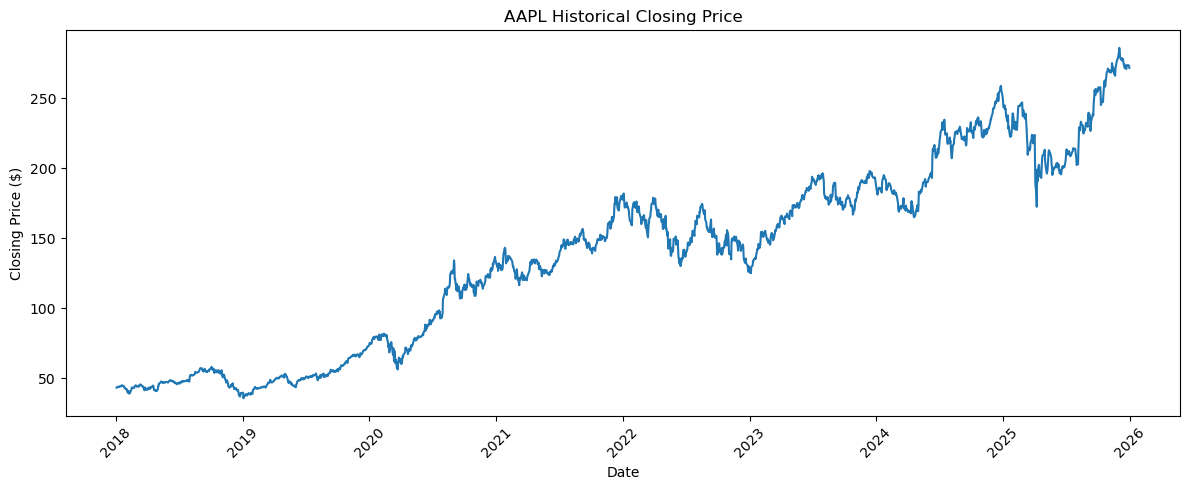

In [34]:

# HISTORICAL CLOSING PRICE
plt.figure(figsize=(12, 5))

plt.plot(
    clean_data["Date"],
    clean_data["Close"],
    linewidth=1.5
)

plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

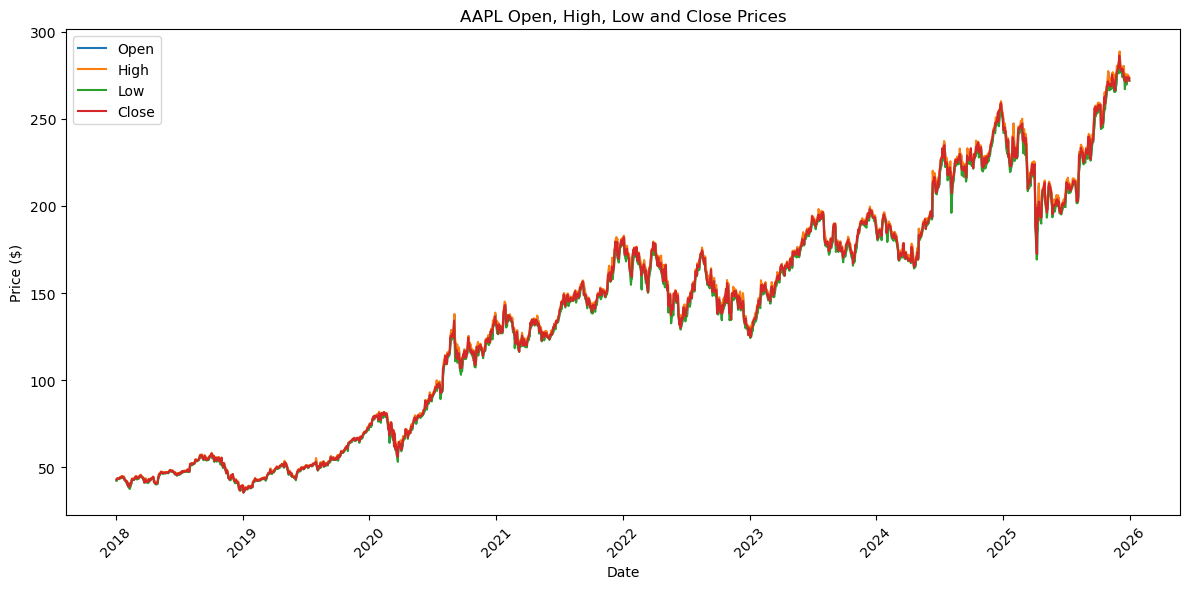

In [36]:

# OPEN, HIGH, LOW AND CLOSE PRICE ANALYSIS
plt.figure(figsize=(12, 6))

plt.plot(
    clean_data["Date"],
    clean_data["Open"],
    label="Open"
)

plt.plot(
    clean_data["Date"],
    clean_data["High"],
    label="High"
)

plt.plot(
    clean_data["Date"],
    clean_data["Low"],
    label="Low"
)

plt.plot(
    clean_data["Date"],
    clean_data["Close"],
    label="Close"
)

plt.title("AAPL Open, High, Low and Close Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


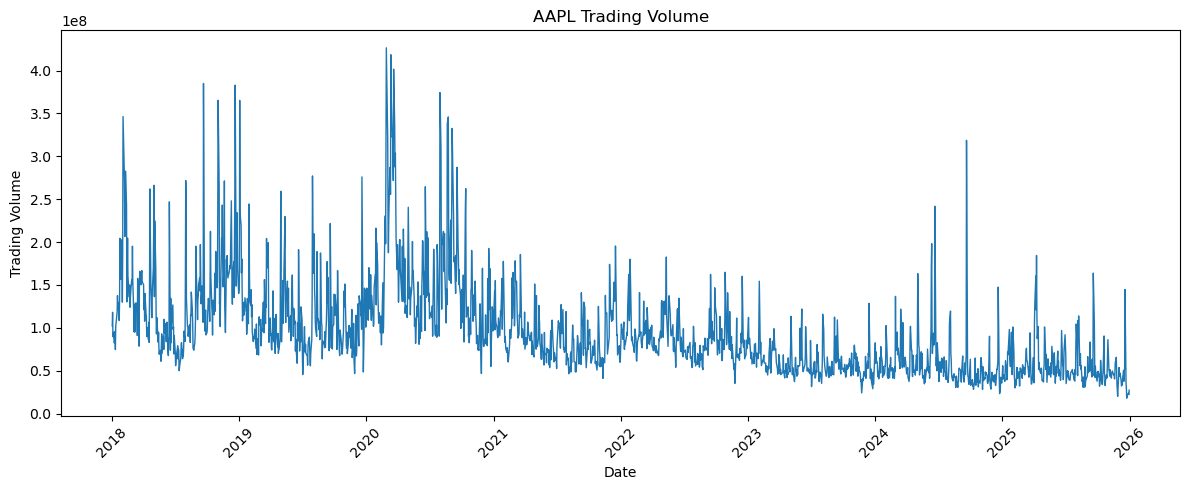

In [38]:

# ============================================
# TRADING VOLUME ANALYSIS
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    clean_data["Date"],
    clean_data["Volume"],
    linewidth=1
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:

# ============================================
# MOVING AVERAGES
# ============================================

clean_data["MA20"] = clean_data["Close"].rolling(
    window=20
).mean()

clean_data["MA50"] = clean_data["Close"].rolling(
    window=50
).mean()

clean_data["MA200"] = clean_data["Close"].rolling(
    window=200
).mean()

print("Moving averages calculated successfully!")


Moving averages calculated successfully!


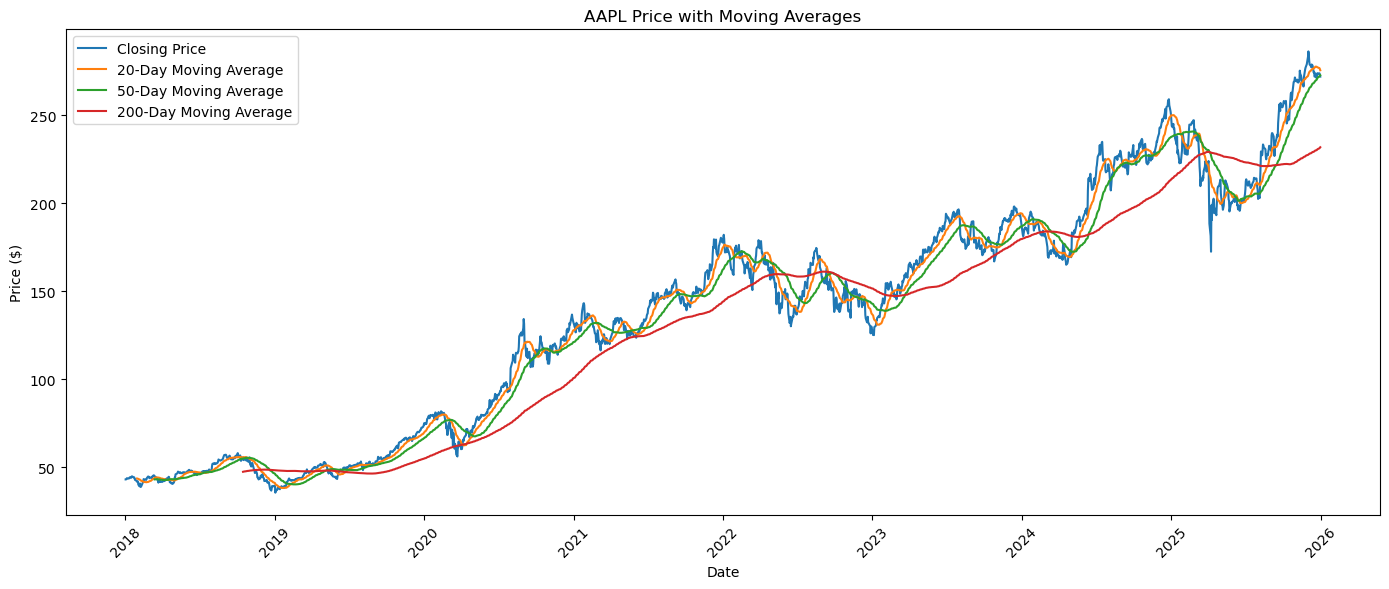

In [42]:

# ============================================
# MOVING AVERAGE VISUALIZATION
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    clean_data["Date"],
    clean_data["Close"],
    label="Closing Price"
)

plt.plot(
    clean_data["Date"],
    clean_data["MA20"],
    label="20-Day Moving Average"
)

plt.plot(
    clean_data["Date"],
    clean_data["MA50"],
    label="50-Day Moving Average"
)

plt.plot(
    clean_data["Date"],
    clean_data["MA200"],
    label="200-Day Moving Average"
)

plt.title("AAPL Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


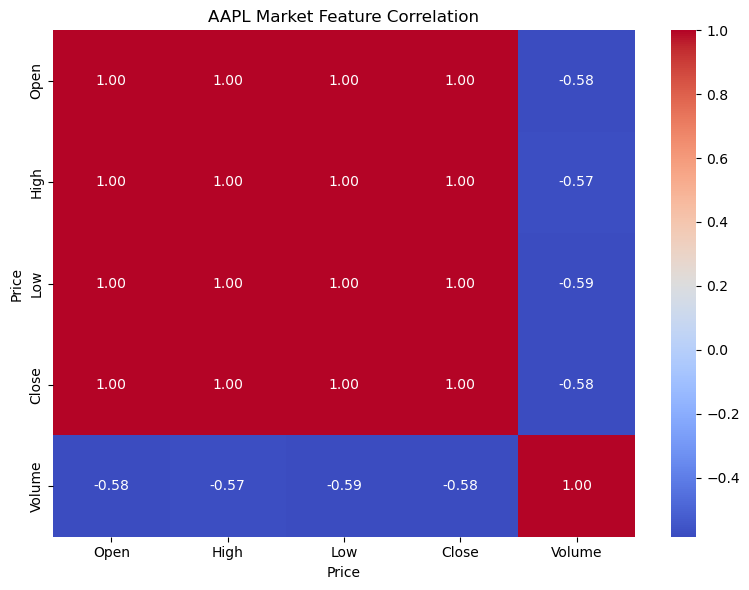

In [44]:

# ============================================
# CORRELATION HEATMAP
# ============================================

correlation_data = clean_data[
    ["Open", "High", "Low", "Close", "Volume"]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("AAPL Market Feature Correlation")

plt.tight_layout()
plt.show()


In [46]:

# ============================================
# BASIC MARKET INSIGHTS
# ============================================

starting_price = clean_data["Close"].iloc[0]
latest_price = clean_data["Close"].iloc[-1]

highest_price = clean_data["High"].max()
lowest_price = clean_data["Low"].min()

average_volume = clean_data["Volume"].mean()

price_change_percentage = (
    (latest_price - starting_price)
    / starting_price
) * 100

print("========== AAPL MARKET INSIGHTS ==========")

print(f"Starting Closing Price : ${starting_price:.2f}")
print(f"Latest Closing Price   : ${latest_price:.2f}")
print(f"Highest Price          : ${highest_price:.2f}")
print(f"Lowest Price           : ${lowest_price:.2f}")
print(f"Average Trading Volume : {average_volume:,.0f}")
print(f"Overall Price Change   : {price_change_percentage:.2f}%")


========== AAPL MARKET INSIGHTS ==========
Starting Closing Price : $43.06
Latest Closing Price   : $271.86
Highest Price          : $288.62
Lowest Price           : $35.50
Average Trading Volume : 94,427,346
Overall Price Change   : 531.28%


In [48]:

# ============================================
# LATEST MOVING AVERAGE VALUES
# ============================================

latest_values = clean_data[
    ["Date", "Close", "MA20", "MA50", "MA200"]
].tail(1)

latest_values



Price,Date,Close,MA20,MA50,MA200
2010,2025-12-31,271.859985,275.472498,272.662199,231.7503


In [50]:
# ============================================
# MACHINE LEARNING DATASET
# ============================================

model_data = clean_data.copy()

# Create the prediction target:
# Next trading day's closing price
model_data["Target"] = model_data["Close"].shift(-1)

print("Target column created successfully!")


Target column created successfully!


In [52]:

# ============================================
# HANDLE MISSING VALUES FROM FEATURE ENGINEERING
# ============================================

model_data = model_data.dropna().reset_index(drop=True)

print("ML dataset shape:", model_data.shape)


ML dataset shape: (1811, 10)


In [54]:

# ============================================
# FEATURE SELECTION
# ============================================

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "MA20",
    "MA50",
    "MA200"
]

X = model_data[features]
y = model_data["Target"]

print("Features used for prediction:")
print(features)

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)


Features used for prediction:
['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'MA200']

Feature dataset shape: (1811, 8)
Target shape: (1811,)


In [56]:

# ============================================
# CHRONOLOGICAL TRAIN/TEST SPLIT
# ============================================

split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(model_data["Date"].iloc[0], "to",
      model_data["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(model_data["Date"].iloc[split_index], "to",
      model_data["Date"].iloc[-1])


Training samples: 1448
Testing samples: 363

Training period:
2018-10-16 00:00:00 to 2024-07-19 00:00:00

Testing period:
2024-07-22 00:00:00 to 2025-12-30 00:00:00


In [58]:

# ============================================
# FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


# 🤖 Machine Learning Model Development

Three regression algorithms are evaluated:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

In [62]:
# ============================================
# LINEAR REGRESSION
# ============================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Linear Regression trained successfully!")


Linear Regression trained successfully!


In [64]:
# ============================================
# DECISION TREE REGRESSION
# ============================================

decision_tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(
    X_train_scaled,
    y_train
)

decision_tree_predictions = decision_tree_model.predict(
    X_test_scaled
)

print("Decision Tree Regression trained successfully!")


Decision Tree Regression trained successfully!


In [66]:

# ============================================
# RANDOM FOREST REGRESSION
# ============================================

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_scaled,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test_scaled
)

print("Random Forest Regression trained successfully!")


Random Forest Regression trained successfully!


In [70]:

# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }


In [74]:

# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)

results_df = pd.DataFrame(results)

results_df



,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,2.668163,15.744228,3.967900,0.969684
1,Decision Tree,16.269240,504.699963,22.465528,0.028184
2,Random Forest,12.516801,353.429987,18.799734,0.319459


In [76]:
# ============================================
# SELECT BEST MODEL
# ============================================

best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Best performing model based on RMSE:")
print(best_model_name)


Best performing model based on RMSE:
Linear Regression


In [78]:

# ============================================
# ACTUAL VS PREDICTED VALUES
# ============================================

prediction_comparison = pd.DataFrame({
    "Date": model_data["Date"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Linear Regression": linear_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
})

prediction_comparison.head()


,Date,Actual,Linear Regression,Decision Tree,Random Forest
0,2024-07-22,225.009995,223.913856,223.960007,225.585552
1,2024-07-23,218.539993,225.179463,223.960007,225.308602
2,2024-07-24,217.490005,218.096833,226.339996,224.490752
3,2024-07-25,217.960007,217.180819,226.339996,222.423902
4,2024-07-26,218.240005,217.847133,226.339996,222.299251


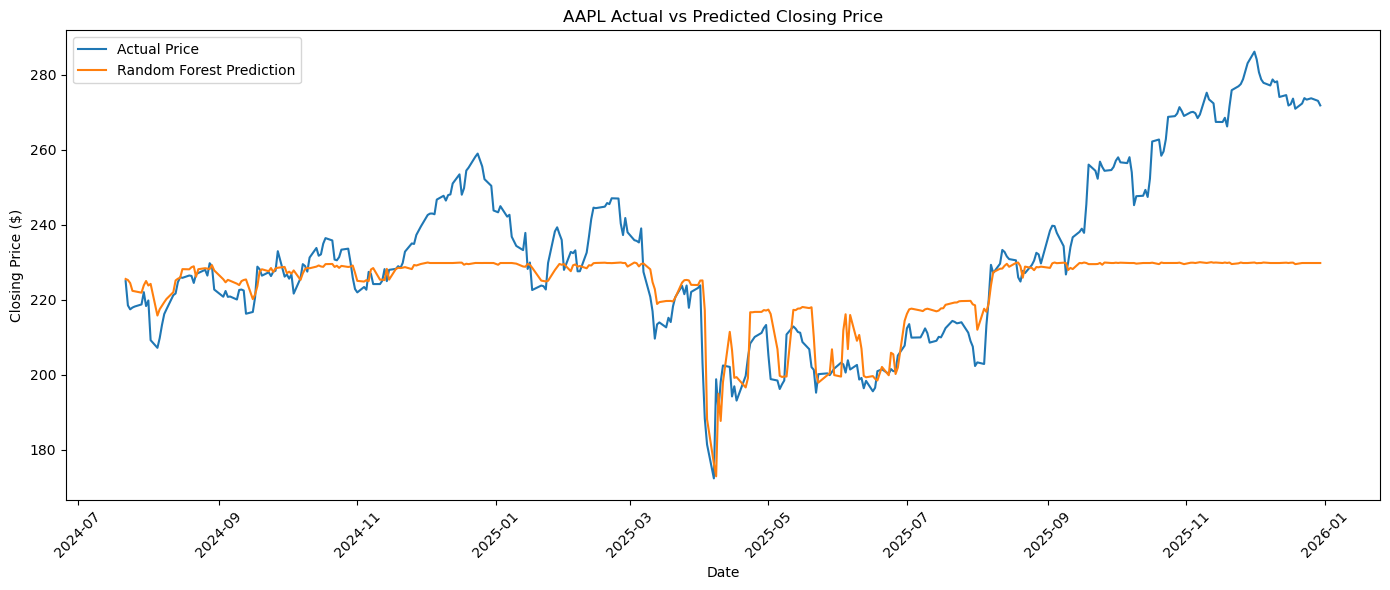

In [80]:

# ============================================
# ACTUAL VS PREDICTED - RANDOM FOREST
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Actual"],
    label="Actual Price"
)

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Random Forest"],
    label="Random Forest Prediction"
)

plt.title("AAPL Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



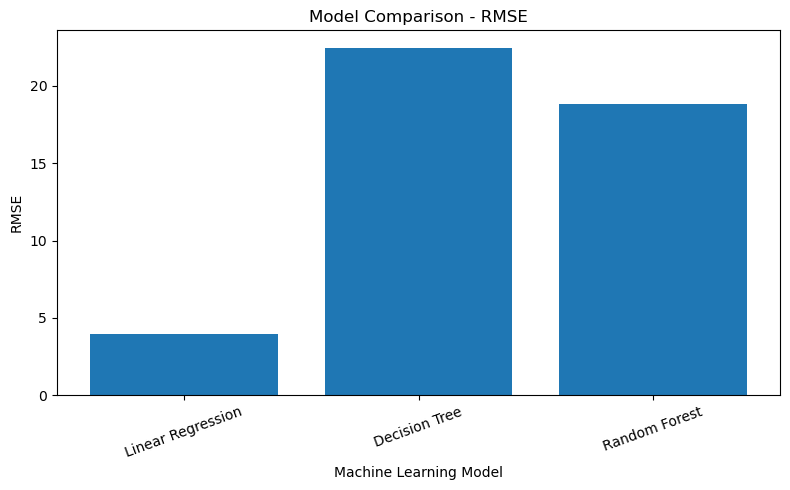

In [82]:
# ============================================
# MODEL RMSE COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [84]:
# ============================================
# ACTUAL VS PREDICTED - BEST MODEL
# ============================================

# Get predictions from the best model
best_predictions = linear_predictions

prediction_comparison = pd.DataFrame({
    "Date": model_data["Date"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

prediction_comparison.head()


,Date,Actual,Predicted
0,2024-07-22,225.009995,223.913856
1,2024-07-23,218.539993,225.179463
2,2024-07-24,217.490005,218.096833
3,2024-07-25,217.960007,217.180819
4,2024-07-26,218.240005,217.847133


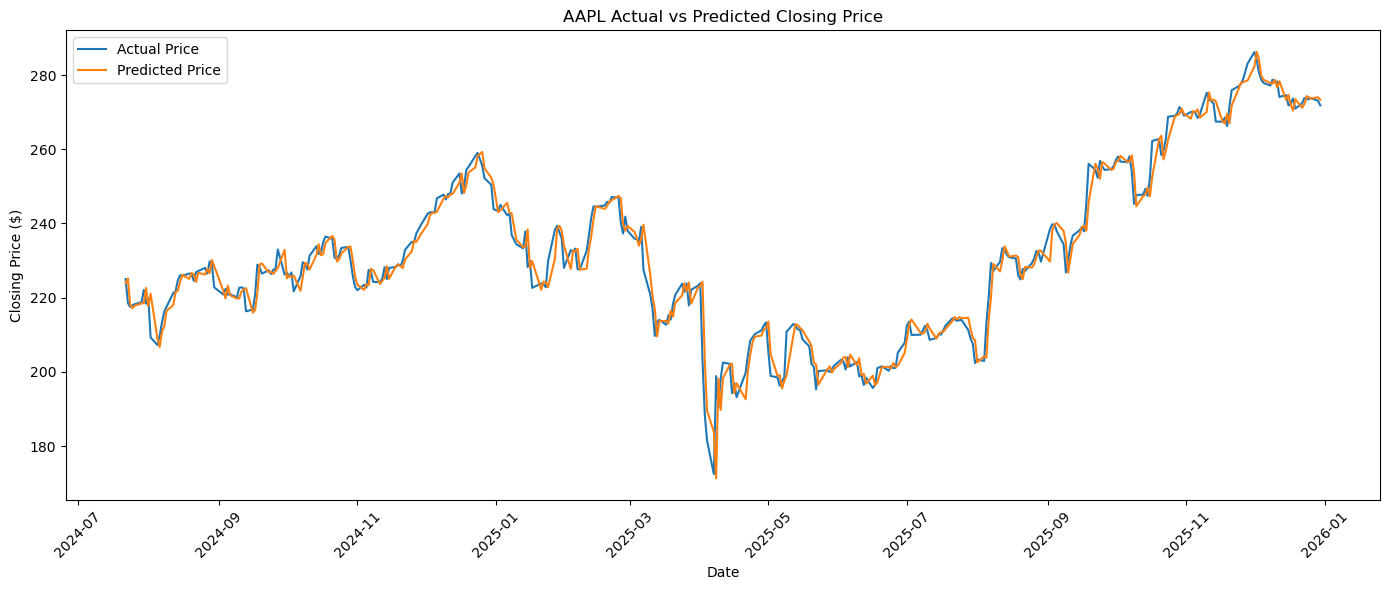

In [86]:
# ============================================
# ACTUAL VS PREDICTED PRICE
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Actual"],
    label="Actual Price"
)

plt.plot(
    prediction_comparison["Date"],
    prediction_comparison["Predicted"],
    label="Predicted Price"
)

plt.title("AAPL Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

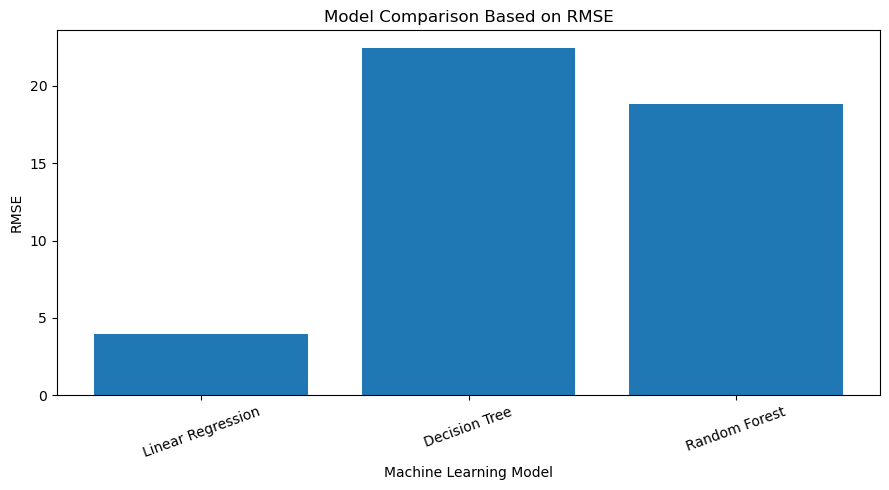

In [88]:
# ============================================
# MODEL RMSE COMPARISON
# ============================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [90]:
# SAVE BEST MODEL
best_model = linear_model

joblib.dump(
    best_model,
    "../models/linear_regression_stock_model.pkl"
)

joblib.dump(
    scaler,
    "../models/stock_feature_scaler.pkl"
)

joblib.dump(
    features,
    "../models/stock_feature_columns.pkl"
)

print("Best model saved successfully!")
print("Model: Linear Regression")

Best model saved successfully!
Model: Linear Regression


In [92]:

# SAVE MODEL PERFORMANCE RESULTS
results_df.to_csv(
    "../models/model_performance.csv",
    index=False
)

print("Model performance results saved successfully!")

Model performance results saved successfully!
